# Project: Finding Donors for *CharityML*

Welcome to the first project of the Data Scientist Nanodegree! In this notebook, some template code has already been provided for you, and it will be your job to implement the additional functionality necessary to successfully complete this project. Sections that begin with **'Implementation'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section and the specifics of the implementation are marked in the code block with a `TODO` statement. Please be sure to read the instructions carefully!

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.  

>**Note:** Please specify **WHICH VERSION OF PYTHON** you are using when submitting this notebook. Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut. In addition, Markdown cells can be edited by typically double-clicking the cell to enter edit mode.

## Getting Started

In this project, you will employ several supervised algorithms of your choice to accurately model individuals' income using data collected from the 1994 U.S. Census. You will then choose the best candidate algorithm from preliminary results and further optimize this algorithm to best model the data. Your goal with this implementation is to construct a model that accurately predicts whether an individual makes more than $50,000. This sort of task can arise in a non-profit setting, where organizations survive on donations.  Understanding an individual's income can help a non-profit better understand how large of a donation to request, or whether or not they should reach out to begin with.  While it can be difficult to determine an individual's general income bracket directly from public sources, we can (as we will see) infer this value from other publically available features. 

The dataset for this project originates from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Census+Income). The datset was donated by Ron Kohavi and Barry Becker, after being published in the article _"Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid"_. You can find the article by Ron Kohavi [online](https://www.aaai.org/Papers/KDD/1996/KDD96-033.pdf). The data we investigate here consists of small changes to the original dataset, such as removing the `fnlwgt` feature and records with missing or ill-formatted entries.

----
## Exploring the Data
Run the code cell below to load necessary Python libraries and load the census data. Note that the last column from this dataset, `income`, will be our target label (whether an individual makes more than, or at most, $50,000 annually). All other columns are features about each individual in the census database.

In [ ]:
# Import libraries necessary for this project
import sys
import numpy as np
import pandas as pd
import seaborn as sns
from time import time
from IPython.display import display  # Allows the use of display() for DataFrames
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

# Import supplementary visualization code visuals.py
import src.visuals as vs

# seaborn theme for plots
sns.set_theme(style="whitegrid", palette="Blues")

# Pretty display for notebooks
%matplotlib inline

# Load the Census dataset
DATA_PATH = Path("/home/fabiolima/Desktop/Finding_Donors_Project/data/census.csv")
data = pd.read_csv(DATA_PATH)

# Success - Display the first record
display(data.head(n=1))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K


**Known premises from context:**
- This is a supervised binary classification problem.
- The target is to predict whether an individual earns `>50K` per year.
- The intended use is to support contact prioritization for CharityML.
- The most appropriate business metric is `F-beta` with `beta = 0.5`, since false positives represent letters sent with no expected return.

### Implementation: Data Exploration
A cursory investigation of the dataset will determine how many individuals fit into either group, and will tell us about the percentage of these individuals making more than \$50,000. In the code cell below, you will need to compute the following:
- The total number of records, `n_records`
- The number of individuals making more than \$50,000 annually, `n_greater_50k`.
- The number of individuals making at most \$50,000 annually, `n_at_most_50k`.
- The percentage of individuals making more than \$50,000 annually, `greater_percent`.

**HINT:** You may need to look at the table above to understand how the `income` entries are formatted. 

In [3]:
# TODO: Total number of records
n_records = len(data)

# Income distribution using value_counts for a single pass -- income is str variable
income_counts = data["income"].value_counts()

# TODO: Number of records where individual's income is more than $50,000
n_greater_50k = income_counts[">50K"]

# TODO: Number of records where individual's income is at most $50,000
n_at_most_50k = income_counts["<=50K"]

# TODO: Percentage of individuals whose income is more than $50,000
greater_percent = round(n_greater_50k / n_records * 100, 2)

# Print the results
print("Total number of records: {}".format(n_records))
print("Individuals making more than $50,000: {}".format(n_greater_50k))
print("Individuals making at most $50,000: {}".format(n_at_most_50k))
print("Percentage of individuals making more than $50,000: {}%".format(greater_percent))

Total number of records: 45222
Individuals making more than $50,000: 11208
Individuals making at most $50,000: 34014
Percentage of individuals making more than $50,000: 24.78%


In [4]:
income_table = (
    data["income"]
    .value_counts()
    .rename_axis("income")
    .reset_index(name="count")
    .assign(percent=lambda df: round(df["count"] / len(data) * 100, 2))
)

display(income_table)


,income,count,percent
0,<=50K,34014,75.22
1,>50K,11208,24.78


The target variable `income` is imbalanced: approximately 75% of individuals earn `<=50K`
and only ~25% earn `>50K`. This class imbalance will be taken into consideration
during model selection and evaluation.

**Featureset Exploration**

* **age**: continuous. 
* **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. 
* **education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. 
* **education-num**: continuous. 
* **marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. 
* **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. 
* **relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. 
* **race**: Black, White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other. 
* **sex**: Female, Male. 
* **capital-gain**: continuous. 
* **capital-loss**: continuous. 
* **hours-per-week**: continuous. 
* **native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

| Feature | Type | Semantic Group | Meaning |
|---|---|---|---|
| `age` | Continuous | Demographic | Individual's age in years |
| `sex` | Binary | Demographic | Biological sex (Female / Male) |
| `race` | Categorical | Demographic | Self-identified racial group |
| `native-country` | Categorical | Demographic | Country of origin |
| `workclass` | Categorical | Socioeconomic | Employment sector |
| `occupation` | Categorical | Socioeconomic | Type of work performed |
| `hours-per-week` | Continuous | Socioeconomic | Average hours worked per week |
| `education` | Categorical (ordinal) | Education | Highest level of education attained |
| `education-num` | Continuous | Education | Numeric encoding of education level |
| `marital-status` | Categorical | Family / Social | Current marital status |
| `relationship` | Categorical | Family / Social | Role within the household |
| `capital-gain` | Continuous | Financial | Income from capital asset investments |
| `capital-loss` | Continuous | Financial | Losses from capital asset sales |


----
## Preparing the Data
Before data can be used as input for machine learning algorithms, it often must be cleaned, formatted, and restructured — this is typically known as **preprocessing**. Fortunately, for this dataset, there are no invalid or missing entries we must deal with, however, there are some qualities about certain features that must be adjusted. This preprocessing can help tremendously with the outcome and predictive power of nearly all learning algorithms.

### Transforming Skewed Continuous Features
A dataset may sometimes contain at least one feature whose values tend to lie near a single number, but will also have a non-trivial number of vastly larger or smaller values than that single number.  Algorithms can be sensitive to such distributions of values and can underperform if the range is not properly normalized. With the census dataset two features fit this description: `capital-gain` and `capital-loss`. 

Run the code cell below to plot a histogram of these two features. Note the range of the values present and how they are distributed.

/home/fabiolima/Desktop/Finding_Donors_Project/src/visuals.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


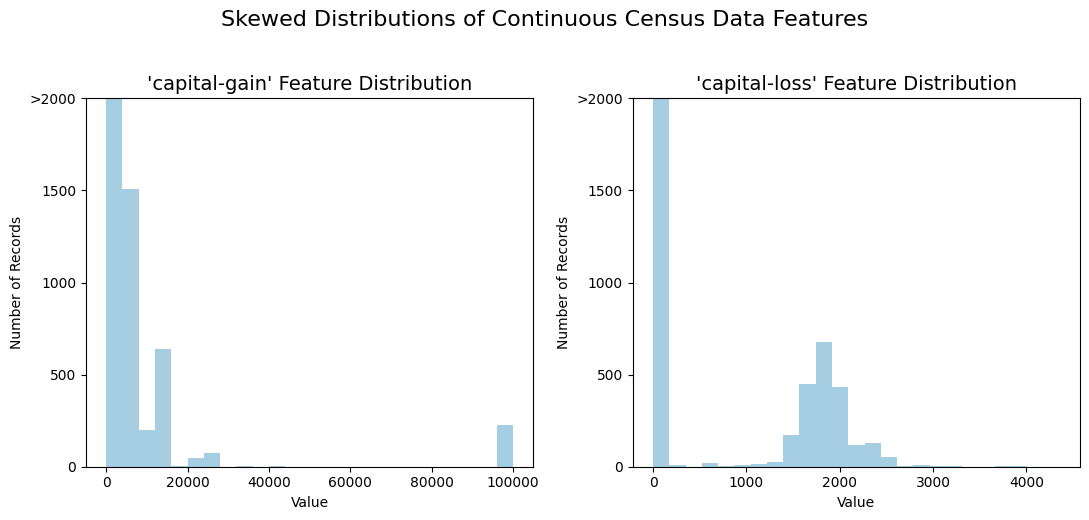

In [5]:
# Split the data into features and target label
income_raw = data["income"]
features_raw = data.drop("income", axis=1)

# Visualize skewed continuous features of original data
vs.distribution(data)

For highly-skewed feature distributions such as `capital-gain` and `capital-loss`, it is common practice to apply a [logarithmic transformation](https://en.wikipedia.org/wiki/Data_transformation_(statistics)) on the data so that the very large and very small values do not negatively affect the performance of a learning algorithm. Using a logarithmic transformation significantly reduces the range of values caused by outliers. Care must be taken when applying this transformation however: The logarithm of 0 is undefined, so we must translate the values by a small amount above 0 to apply the the logarithm successfully.

Run the code cell below to perform a transformation on the data and visualize the results. Again, note the range of values and how they are distributed. 

/home/fabiolima/Desktop/Finding_Donors_Project/src/visuals.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


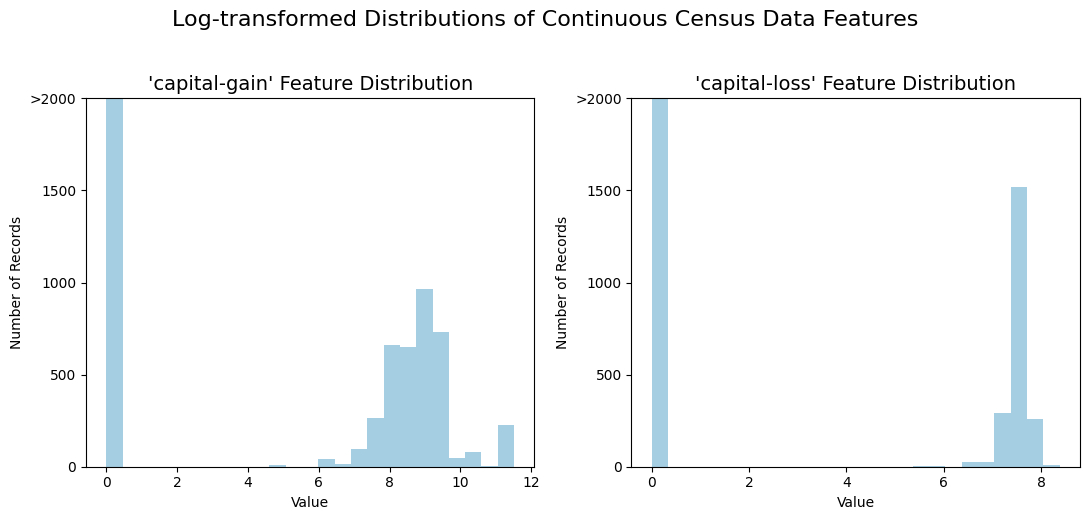

In [6]:
# Log-transform the skewed features
skewed = ["capital-gain", "capital-loss"]
features_log_transformed = pd.DataFrame(data=features_raw)
features_log_transformed[skewed] = features_raw[skewed].apply(lambda x: np.log(x + 1))

# Visualize the new log distributions
vs.distribution(features_log_transformed, transformed=True)

### Normalizing Numerical Features
In addition to performing transformations on features that are highly skewed, it is often good practice to perform some type of scaling on numerical features. Applying a scaling to the data does not change the shape of each feature's distribution (such as `capital-gain` or `capital-loss` above); however, normalization ensures that each feature is treated equally when applying supervised learners. Note that once scaling is applied, observing the data in its raw form will no longer have the same original meaning, as exampled below.

Run the code cell below to normalize each numerical feature. We will use [`sklearn.preprocessing.MinMaxScaler`](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) for this.

In [7]:
# Import sklearn.preprocessing.StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Initialize a scaler, then apply it to the features
scaler = MinMaxScaler()  # default=(0, 1)
numerical = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

features_log_minmax_transform = pd.DataFrame(data=features_log_transformed)
features_log_minmax_transform[numerical] = scaler.fit_transform(
    features_log_transformed[numerical]
)

# Show an example of a record with scaling applied
display(features_log_minmax_transform.head(n=5))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.301370,State-gov,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.667492,0.0,0.397959,United-States
1,0.452055,Self-emp-not-inc,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,0.122449,United-States
2,0.287671,Private,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,0.397959,United-States
3,0.493151,Private,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,0.397959,United-States
4,0.150685,Private,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,0.397959,Cuba


### Implementation: Data Preprocessing

From the table in **Exploring the Data** above, we can see there are several features for each record that are non-numeric. Typically, learning algorithms expect input to be numeric, which requires that non-numeric features (called *categorical variables*) be converted. One popular way to convert categorical variables is by using the **one-hot encoding** scheme. One-hot encoding creates a _"dummy"_ variable for each possible category of each non-numeric feature. For example, assume `someFeature` has three possible entries: `A`, `B`, or `C`:

|   | someFeature |                    
| :-: | :-: |                            
| 0 |  B  |  
| 1 |  C  |
| 2 |  A  |  

We then encode this feature into `someFeature_A`, `someFeature_B` and `someFeature_C`:

|| someFeature_A | someFeature_B | someFeature_C |
| :-: | :-: | :-: | :-: |
|0| 0 | 1 | 0 |
|1| 0 | 0 | 1 |
|2| 1 | 0 | 0 |

Additionally, as with the non-numeric features, we need to convert the non-numeric target label, `income` to numerical values for the learning algorithm to work. Since there are only two possible categories for this label ("<=50K" and ">50K"), we can avoid using one-hot encoding and simply encode these two categories as 0 and 1, respectively. In code cell below, you will need to implement the following:
 - Use [`pandas.get_dummies()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html?highlight=get_dummies#pandas.get_dummies) to perform one-hot encoding on the `features_log_minmax_transform` data.
 - Convert the target label `income_raw` to numerical entries.
   - Set records with "<=50K" to 0 and records with ">50K" to 1.

In [ ]:
# One-hot encode the 'features_log_minmax_transform' data using pandas.get_dummies()
features_final = pd.get_dummies(features_log_minmax_transform)

# Encode the 'income_raw' data to numerical values
income = income_raw.map({"<=50K": 0, ">50K": 1})  # class 1 as positive

# Print the number of features after one-hot encoding
encoded = list(features_final.columns)
print("{} total features after one-hot encoding.".format(len(encoded)))


103 total features after one-hot encoding.


### Shuffle and Split Data
Now all _categorical variables_ have been converted into numerical features, and all numerical features have been normalized. As always, we will now split the data (both features and their labels) into training and test sets. 80% of the data will be used for training and 20% for testing.

Run the code cell below to perform this split.

In [9]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the 'features' and 'income' data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    features_final, income, test_size=0.2, random_state=0, stratify=income
)


# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 36177 samples.
Testing set has 9045 samples.


Since the target variable `income` is imbalanced (~75% `<=50K`, ~25% `>50K`),
we use `stratify=income` to ensure that both the training and testing sets preserve
the same class proportions as the original dataset. Without stratification, a random
split could produce sets with skewed distributions, leading to unreliable evaluation metrics.

----
## Evaluating Model Performance
In this section, we will investigate four different algorithms, and determine which is best at modeling the data. Three of these algorithms will be supervised learners of your choice, and the fourth algorithm is known as a *naive predictor*.

### Confusion Matrix

![Confusion Matrix](../imgs/confusion_matrix.png)

### Metrics and the Naive Predictor

*CharityML*, equipped with their research, knows individuals that make more than \$50,000 are most likely to donate to their charity. Because of this, *CharityML* is particularly interested in predicting who makes more than \$50,000 accurately. It would seem that using **accuracy** as a metric for evaluating a particular model's performace would be appropriate. Additionally, identifying someone that *does not* make more than \$50,000 as someone who does would be detrimental to *CharityML*, since they are looking to find individuals willing to donate. Therefore, a model's ability to precisely predict those that make more than \$50,000 is *more important* than the model's ability to **recall** those individuals. We can use **F-beta score** as a metric that considers both precision and recall:

$$ F_{\beta} = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{\left( \beta^2 \cdot \text{precision} \right) + \text{recall}} $$

In particular, when $\beta = 0.5$, more emphasis is placed on precision. This is called the $F_{0.5}$ score (or F-score for simplicity).

Looking at the distribution of classes (those who make at most \\$50,000, and those who make more), it's clear most individuals do not make more than \$50,000. This can greatly affect **accuracy**, since we could simply say *"this person does not make more than \$50,000"* and generally be right, without ever looking at the data! Making such a statement would be called **naive**, since we have not considered any information to substantiate the claim. It is always important to consider the *naive prediction* for your data, to help establish a benchmark for whether a model is performing well. That been said, using that prediction would be pointless: If we predicted all people made less than \$50,000, *CharityML* would identify no one as donors. 


#### Note: Recap of accuracy, precision, recall

**Accuracy** measures how often the classifier makes the correct prediction. It’s the ratio of the number of correct predictions to the total number of predictions (the number of test data points).

**Precision** tells us what proportion of messages we classified as spam, actually were spam.
It is a ratio of true positives (words classified as spam, and which are actually spam) to all positives (all words classified as spam, irrespective of whether that was the correct classificatio), in other words it is the ratio of

$$\text{Precision} = \frac{\text{True Positives}} {\text{True Positives} + \text{False Positives}}$$

**Recall (sensitivity)** tells us what proportion of messages that actually were spam were classified by us as spam.
It is a ratio of true positives (words classified as spam, and which are actually spam) to all the words that were actually spam, in other words it is the ratio of

$$\text{Recall} = \frac{\text{True Positives}} {\text{True Positives} + \text{False Negatives}}$$

For classification problems that are skewed in their classification distributions, like in our case, for example, if we had 100 text messages and only 2 were spam and the remaining 98 weren't, accuracy is not a very good metric. We could classify 90 messages as not spam (including the 2 that were spam, but we classify them as not spam, hence they would be false negatives) and 10 as spam (all 10 false positives) and still get a reasonably good accuracy score. For such cases, precision and recall come in very handy. These two metrics can be combined to get the F1 score and the weighted average (harmonic mean) of the precision and recall scores. This score can range from 0 to 1, with 1 being the best possible F1 score(we take the harmonic mean when dealing with ratios).

### Question 1 - Naive Predictor Performance
* If we chose a model that always predicted an individual made more than $50,000, what would  that model's accuracy and F-score be on this dataset? You must use the code cell below and assign your results to `accuracy` and `fscore` to be used later.

**Please note** that the the purpose of generating a naive predictor is simply to show what a base model without any intelligence would look like. In the real world, ideally your base model would be either the results of a previous model or could be based on a research paper upon which you are looking to improve. When there is no benchmark model set, getting a result better than random choice is a place you could start from.

**HINT:** 

* When we have a model that always predicts 1 (i.e., the individual makes more than 50k) then our model will have no True Negatives (TN) or False Negatives (FN) as we are not making any negative (0 value) predictions. Therefore our Accuracy in this case becomes the same as our Precision (True Positives / (True Positives + False Positives)) as every prediction that we have made with value 1 that should have 0 becomes a False Positive; therefore our denominator in this case is the total number of records we have in total. 
* Our Recall score (True Positives / (True Positives + False Negatives)) in this setting becomes 1 as we have no False Negatives.

In [10]:
TP = np.sum(
    income
)  # Counting the ones as this is the naive case. Note that 'income' is the 'income_raw' data encoded to numerical values done in the data preprocessing step.
FP = income.count() - TP  # Specific to the naive case

TN = 0  # No predicted negatives in the naive case
FN = 0  # No predicted negatives in the naive case

# TODO: Calculate accuracy, precision and recall
accuracy = (TP + TN) / (TP + TN + FP + FN)
recall = TP / (TP + FN)
precision = TP / (TP + FP)

# TODO: Calculate F-score using the formula above for beta = 0.5 and correct values for precision and recall.
beta = 0.5
fscore = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

# Print the results
print(
    "Naive Predictor: [Accuracy score: {:.4f}, F-score: {:.4f}]".format(
        accuracy, fscore
    )
)

Naive Predictor: [Accuracy score: 0.2478, F-score: 0.2917]


###  Supervised Learning Models
**The following are some of the supervised learning models that are currently available in** [scikit-learn](http://scikit-learn.org/stable/supervised_learning.html) **that you may choose from:**
- Gaussian Naive Bayes (GaussianNB)
- Decision Trees
- Ensemble Methods (Bagging, AdaBoost, Random Forest, Gradient Boosting)
- K-Nearest Neighbors (KNeighbors)
- Stochastic Gradient Descent Classifier (SGDC)
- Support Vector Machines (SVM)
- Logistic Regression

### Question 2 - Model Application
List three of the supervised learning models above that are appropriate for this problem that you will test on the census data. For each model chosen

- Describe one real-world application in industry where the model can be applied. 
- What are the strengths of the model; when does it perform well?
- What are the weaknesses of the model; when does it perform poorly?
- What makes this model a good candidate for the problem, given what you know about the data?

**HINT:**

Structure your answer in the same format as above^, with 4 parts for each of the three models you pick. Please include references with your answer.

**Answer:**

1. Logistic Regression

**Real-world application in industry**
Logistic Regression is widely used in banking, insurance, and marketing for binary classification tasks such as credit default prediction, churn prediction, and campaign response modeling. In this context, it can be used to estimate the probability that an individual earns more than $50,000 and is therefore more likely to be a strong donation prospect.

**Strengths and when it performs well**
Logistic Regression is simple, fast to train, and easy to interpret. Its coefficients provide a clear directional view of how each feature affects the probability of belonging to the positive class. It performs well when the relationship between predictors and the log-odds of the target is approximately linear, and it is especially useful as a strong baseline model for binary classification.

**Weaknesses and when it performs poorly**
Its main limitation is that it may underperform when the true decision boundary is highly non-linear or when there are complex interactions among variables. It can also be sensitive to multicollinearity and may require feature engineering to fully capture patterns in the data.

**Why it is a good candidate for this problem**
This dataset is a binary classification problem with structured census features that have already been preprocessed into numeric form. Logistic Regression is a very good first benchmark because it is computationally efficient, provides interpretable results, and allows us to assess whether a simple linear model is already sufficient before moving to more complex ensemble methods.

___

2. Random Forest Classifier

**Real-world application in industry**
Random Forest is commonly used in fraud detection, customer segmentation, credit risk screening, and healthcare risk prediction. For this project, it is a strong candidate because it can capture more complex relationships between demographic and socioeconomic variables and income level.

**Strengths and when it performs well**
Random Forest is robust, flexible, and usually performs well on tabular datasets with mixed signal strength across features. Because it averages many decision trees, it reduces overfitting compared with a single tree and can model non-linear effects and feature interactions without heavy preprocessing. It is also relatively insensitive to monotonic transformations and does not depend strongly on feature scaling. In addition, it provides feature importance estimates, which is very useful for understanding which variables contribute most to income prediction.

**Weaknesses and when it performs poorly**
Its main weaknesses are reduced interpretability compared with simpler models and higher computational cost than Logistic Regression. It can also produce less well-calibrated probabilities and may struggle when classes are highly imbalanced unless hyperparameters or class weights are handled carefully.

**Why it is a good candidate for this problem**
The census dataset likely contains non-linear relationships and interaction effects, such as the combined effect of education, occupation, hours worked, and marital status. Random Forest can capture those patterns well while still being relatively stable and easy to use. It also aligns well with the business goal because it often delivers strong precision-oriented performance and offers feature importance analysis for stakeholder communication.

___

3. Gradient Boosting Classifier

**Real-world application in industry**
Gradient Boosting is widely used in high-performance tabular prediction tasks such as credit scoring, lead scoring, customer conversion prediction, and insurance pricing. In a donor targeting setting, it is especially relevant because it can produce strong ranking and classification performance when the goal is to identify the most promising positive cases.

**Strengths and when it performs well**
Gradient Boosting is one of the strongest general-purpose methods for structured tabular data. It builds trees sequentially so that each new tree focuses on correcting the errors made by the previous ones. This often leads to excellent predictive performance, especially when relationships are non-linear and subtle. It is particularly effective when carefully tuned and can optimize classification performance beyond simpler models.

**Weaknesses and when it performs poorly**
Its main drawbacks are higher training time, greater sensitivity to hyperparameter settings, and lower interpretability than Logistic Regression. It can also overfit if the number of estimators is too large or if trees are too deep, especially without regularization or validation-based tuning.

**Why it is a good candidate for this problem**
This project prioritizes F0.5, which places more emphasis on precision than recall. Gradient Boosting is often a strong choice when the objective is to maximize predictive quality on tabular binary classification tasks, particularly when false positives are costly. Since the donor use case values precise identification of higher-income individuals, Gradient Boosting is a very plausible best-performing candidate despite its higher computational cost.

___

**Why these three models make sense together**
These three models form a balanced comparison set:

* LogisticRegression gives us a fast, interpretable baseline.
* RandomForestClassifier gives us a robust non-linear ensemble with useful feature importance.
* GradientBoostingClassifier gives us a high-performance model that is often very strong on tabular datasets.

This combination is appropriate for the business objective because it lets us compare models not only on predictive quality, but also on training cost, inference cost, and explainability. That is exactly what we need in a donor-screening problem where both model performance and decision transparency matter.







### Implementation - Creating a Training and Predicting Pipeline
To properly evaluate the performance of each model you've chosen, it's important that you create a training and predicting pipeline that allows you to quickly and effectively train models using various sizes of training data and perform predictions on the testing data. Your implementation here will be used in the following section.
In the code block below, you will need to implement the following:
 - Import `fbeta_score` and `accuracy_score` from [`sklearn.metrics`](http://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics).
 - Fit the learner to the sampled training data and record the training time.
 - Perform predictions on the test data `X_test`, and also on the first 300 training points `X_train[:300]`.
   - Record the total prediction time.
 - Calculate the accuracy score for both the training subset and testing set.
 - Calculate the F-score for both the training subset and testing set.
   - Make sure that you set the `beta` parameter!

In [11]:
# TODO: Import two metrics from sklearn - fbeta_score and accuracy_score
from sklearn.metrics import accuracy_score, fbeta_score


def train_predict(learner, sample_size, X_train, y_train, X_test, y_test):
    """
    inputs:
       - learner: the learning algorithm to be trained and predicted on
       - sample_size: the size of samples (number) to be drawn from training set
       - X_train: features training set
       - y_train: income training set
       - X_test: features testing set
       - y_test: income testing set
    """

    results = {}

    # TODO: Fit the learner to the training data using slicing with 'sample_size' using .fit(training_features[:], training_labels[:])
    start = time()  # Get start time
    learner = learner.fit(X_train[:sample_size], y_train[:sample_size])
    end = time()  # Get end time

    # TODO: Calculate the training time
    results["train_time"] = end - start

    # TODO: Get the predictions on the test set(X_test),
    #       then get predictions on the first 300 training samples(X_train) using .predict()
    start = time()  # Get start time
    predictions_test = learner.predict(X_test)
    predictions_train = learner.predict(X_train[:300])
    end = time()  # Get end time

    # TODO: Calculate the total prediction time
    results["pred_time"] = end - start

    # TODO: Compute accuracy on the first 300 training samples which is y_train[:300]
    results["acc_train"] = accuracy_score(y_train[:300], predictions_train)

    # TODO: Compute accuracy on test set using accuracy_score()
    results["acc_test"] = accuracy_score(y_test, predictions_test)

    # TODO: Compute F-score on the the first 300 training samples using fbeta_score()
    results["f_train"] = fbeta_score(y_train[:300], predictions_train, beta=0.5)

    # TODO: Compute F-score on the test set which is y_test
    results["f_test"] = fbeta_score(y_test, predictions_test, beta=0.5)

    # Success
    print("{} trained on {} samples.".format(learner.__class__.__name__, sample_size))

    # Return the results
    return results

### Implementation: Initial Model Evaluation
In the code cell, you will need to implement the following:
- Import the three supervised learning models you've discussed in the previous section.
- Initialize the three models and store them in `clf_A`, `clf_B`, and `clf_C`.
  - Use a `random_state` for each model you use, if provided.
  - **Note:** Use the default settings for each model — you will tune one specific model in a later section.
- Calculate the number of records equal to 1%, 10%, and 100% of the training data.
  - Store those values in `samples_1`, `samples_10`, and `samples_100` respectively.

**Note:** Depending on which algorithms you chose, the following implementation may take some time to run!

LogisticRegression trained on 361 samples.
LogisticRegression trained on 3617 samples.
LogisticRegression trained on 36177 samples.
RandomForestClassifier trained on 361 samples.
RandomForestClassifier trained on 3617 samples.
RandomForestClassifier trained on 36177 samples.
GradientBoostingClassifier trained on 361 samples.
GradientBoostingClassifier trained on 3617 samples.
GradientBoostingClassifier trained on 36177 samples.


/home/fabiolima/Desktop/Finding_Donors_Project/src/visuals.py:122: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  pl.tight_layout()


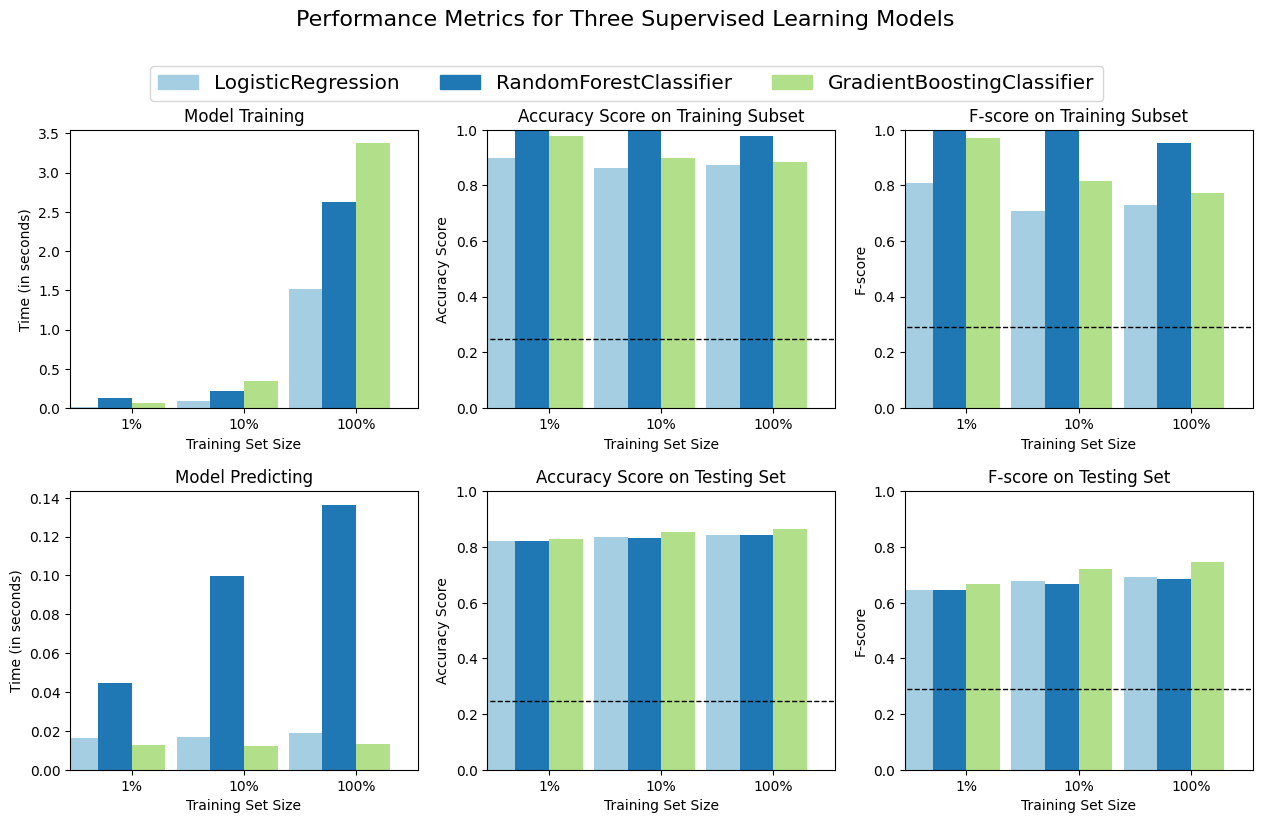

In [12]:
# TODO: Import the three supervised learning models from sklearn
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# TODO: Initialize the three models
clf_A = LogisticRegression(random_state=42)
clf_B = RandomForestClassifier(random_state=42)
clf_C = GradientBoostingClassifier(random_state=42)

# TODO: Calculate the number of samples for 1%, 10%, and 100% of the training data
# HINT: samples_100 is the entire training set i.e. len(y_train)
# HINT: samples_10 is 10% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
# HINT: samples_1 is 1% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
samples_100 = len(y_train)
samples_10 = int(len(y_train) * 0.1)
samples_1 = int(len(y_train) * 0.01)

# Collect results on the learners
results = {}
for clf in [clf_A, clf_B, clf_C]:
    clf_name = clf.__class__.__name__
    results[clf_name] = {}
    for i, samples in enumerate([samples_1, samples_10, samples_100]):
        results[clf_name][i] = train_predict(
            clf, samples, X_train, y_train, X_test, y_test
        )

# Run metrics visualization for the three supervised learning models chosen
vs.evaluate(results, accuracy, fscore)

----
## Improving Results
In this final section, you will choose from the three supervised learning models the *best* model to use on the student data. You will then perform a grid search optimization for the model over the entire training set (`X_train` and `y_train`) by tuning at least one parameter to improve upon the untuned model's F-score. 

### Question 3 - Choosing the Best Model

* Based on the evaluation you performed earlier, in one to two paragraphs, explain to *CharityML* which of the three models you believe to be most appropriate for the task of identifying individuals that make more than $50,000. 

**HINT:** 
Look at the graph at the bottom left from the cell above(the visualization created by `vs.evaluate(results, accuracy, fscore)`) and check the F score for the testing set when 100% of the training set is used. Which model has the highest score? Your answer should include discussion of the:
* metrics - F score on the testing when 100% of the training data is used, 
* prediction/training time
* the algorithm's suitability for the data.

**Answer:**

`GradientBoostingClassifier` appears to be the most appropriate model for CharityML. Among the three models evaluated, it achieved the highest F-score on the testing set when trained on 100% of the available training data, which is the most important criterion in this project because the `F0.5` score places more emphasis on precision than recall. This is especially relevant for CharityML, since incorrectly identifying low-income individuals as likely donors would be more costly than missing some potential donors. In addition to the best testing F-score, Gradient Boosting also produced the highest testing accuracy, indicating that it generalizes better to unseen data than the other candidates.

In terms of computational cost, `GradientBoostingClassifier` required more training time than `LogisticRegression` and `RandomForestClassifier`, although its prediction time remained low and practical for this task. While `LogisticRegression` was faster and easier to interpret, its overall predictive performance was weaker. `RandomForestClassifier` performed extremely well on the training subsets, but its lower testing F-score suggests that it did not generalize as effectively as Gradient Boosting. Since this problem uses structured tabular census data with potentially non-linear relationships between variables, `GradientBoostingClassifier` is a strong fit because it can capture complex patterns and deliver the best balance between predictive quality and practical usability.`

### Question 4 - Describing the Model in Layman's Terms

* In one to two paragraphs, explain to *CharityML*, in layman's terms, how the final model chosen is supposed to work. Be sure that you are describing the major qualities of the model, such as how the model is trained and how the model makes a prediction. Avoid using advanced mathematical jargon, such as describing equations.

**HINT:**

When explaining your model, if using external resources please include all citations.

**Answer:** 

`GradientBoostingClassifier `works by building a prediction step by step instead of trying to solve the problem all at once. During training, the model looks at many examples of people in the census data and compares their characteristics, such as education, occupation, marital status, and hours worked per week, with whether they earn more than $50,000. It starts with a simple decision pattern and then adds a series of small adjustments, where each new step focuses on correcting mistakes made by the earlier ones. Over time, this process helps the model become more accurate at identifying the kinds of people who are more likely to belong to the higher-income group.

When the model makes a prediction for a new individual, it reviews that person's information and combines the results of all of those small learned decision steps to reach a final answer. In practical terms, it is like consulting many small decision rules that work together to make a more reliable judgment. This makes the model well suited for CharityML, because income is influenced by several factors that can interact in complex ways, and the model is able to capture those patterns better than a simpler approach.`


### Implementation: Model Tuning
Fine tune the chosen model. Use grid search (`GridSearchCV`) with at least one important parameter tuned with at least 3 different values. You will need to use the entire training set for this. In the code cell below, you will need to implement the following:
- Import [`sklearn.grid_search.GridSearchCV`](http://scikit-learn.org/0.17/modules/generated/sklearn.grid_search.GridSearchCV.html) and [`sklearn.metrics.make_scorer`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html).
- Initialize the classifier you've chosen and store it in `clf`.
 - Set a `random_state` if one is available to the same state you set before.
- Create a dictionary of parameters you wish to tune for the chosen model.
 - Example: `parameters = {'parameter' : [list of values]}`.
 - **Note:** Avoid tuning the `max_features` parameter of your learner if that parameter is available!
- Use `make_scorer` to create an `fbeta_score` scoring object (with $\beta = 0.5$).
- Perform grid search on the classifier `clf` using the `scorer`, and store it in `grid_obj`.
- Fit the grid search object to the training data (`X_train`, `y_train`), and store it in `grid_fit`.

**Note:** Depending on the algorithm chosen and the parameter list, the following implementation may take some time to run!

In [13]:
# TODO: Import 'GridSearchCV', 'make_scorer', and any other necessary libraries
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, fbeta_score, make_scorer
from sklearn.model_selection import GridSearchCV

# TODO: Initialize the classifier
clf = GradientBoostingClassifier(random_state=42)

# TODO: Create the parameters list you wish to tune, using a dictionary if needed.
# HINT: parameters = {'parameter_1': [value1, value2], 'parameter_2': [value1, value2]}
parameters = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
}

# TODO: Make an fbeta_score scoring object using make_scorer()
scorer = make_scorer(fbeta_score, beta=0.5)

# TODO: Perform grid search on the classifier using 'scorer' as the scoring method using GridSearchCV()
grid_obj = GridSearchCV(clf, parameters, scoring=scorer, cv=5)

# TODO: Fit the grid search object to the training data and find the optimal parameters using fit()
grid_fit = grid_obj.fit(X_train, y_train)

# Get the estimator
best_clf = grid_fit.best_estimator_

# Make predictions using the unoptimized and model
predictions = (clf.fit(X_train, y_train)).predict(X_test)
best_predictions = best_clf.predict(X_test)

# Report the before-and-afterscores
print("Unoptimized model\n------")
print(
    "Accuracy score on testing data: {:.4f}".format(accuracy_score(y_test, predictions))
)
print(
    "F-score on testing data: {:.4f}".format(fbeta_score(y_test, predictions, beta=0.5))
)
print("\nOptimized Model\n------")
print(
    "Final accuracy score on the testing data: {:.4f}".format(
        accuracy_score(y_test, best_predictions)
    )
)
print(
    "Final F-score on the testing data: {:.4f}".format(
        fbeta_score(y_test, best_predictions, beta=0.5)
    )
)

Unoptimized model
------
Accuracy score on testing data: 0.8639
F-score on testing data: 0.7461

Optimized Model
------
Final accuracy score on the testing data: 0.8719
Final F-score on the testing data: 0.7581


### Question 5 - Final Model Evaluation

* What is your optimized model's accuracy and F-score on the testing data? 
* Are these scores better or worse than the unoptimized model? 
* How do the results from your optimized model compare to the naive predictor benchmarks you found earlier in **Question 1**?  

**Note:** Fill in the table below with your results, and then provide discussion in the **Answer** box.

#### Results:

|     Metric     | Unoptimized Model | Optimized Model |
| :------------: | :---------------: | :-------------: | 
| Accuracy Score | 0.8639            |      0.8719     |
| F-score        | 0,7461            |      0.7581     |


----
## Feature Importance

An important task when performing supervised learning on a dataset like the census data we study here is determining which features provide the most predictive power. By focusing on the relationship between only a few crucial features and the target label we simplify our understanding of the phenomenon, which is most always a useful thing to do. In the case of this project, that means we wish to identify a small number of features that most strongly predict whether an individual makes at most or more than $50,000.

Choose a scikit-learn classifier (e.g., adaboost, random forests) that has a `feature_importance_` attribute, which is a function that ranks the importance of features according to the chosen classifier.  In the next python cell fit this classifier to training set and use this attribute to determine the top 5 most important features for the census dataset.

### Question 6 - Feature Relevance Observation
When **Exploring the Data**, it was shown there are thirteen available features for each individual on record in the census data. Of these thirteen records, which five features do you believe to be most important for prediction, and in what order would you rank them and why?

**Answer:**

Here is a strong notebook-ready answer in English:

**Answer:**

The five features I would expect to be most important for predicting whether an individual earns more than \$50,000 are `education-num`, `occupation`, `age`, `hours-per-week`, and `marital-status`. I would rank `education-num` first because education level is strongly associated with access to higher-paying jobs and long-term earning potential. I would place `occupation` second, since different professions have very different salary distributions. `Age` would come next because income often rises with experience over time, at least until later stages of a career. `Hours-per-week` is also likely to be highly informative, since people working more hours may be more likely to hold full-time or higher-paying roles. Finally, I would include `marital-status`, because it may indirectly capture differences in household structure, financial responsibility, and life stage that often correlate with income.

This ranking is based on a combination of economic intuition and patterns commonly seen in census-style data. Education and occupation usually provide the strongest direct signal about earnings, while age and hours worked help explain career progression and labor intensity. Marital status is somewhat less direct, but it can still be useful because it may reflect broader demographic and social patterns associated with income levels. Although other variables such as `capital-gain` or `relationship` may also prove important in the fitted model, these five features are the ones I would initially expect to carry the most predictive value.

### Implementation - Extracting Feature Importance
Choose a `scikit-learn` supervised learning algorithm that has a `feature_importance_` attribute availble for it. This attribute is a function that ranks the importance of each feature when making predictions based on the chosen algorithm.

In the code cell below, you will need to implement the following:
 - Import a supervised learning model from sklearn if it is different from the three used earlier.
 - Train the supervised model on the entire training set.
 - Extract the feature importances using `.feature_importances_`.

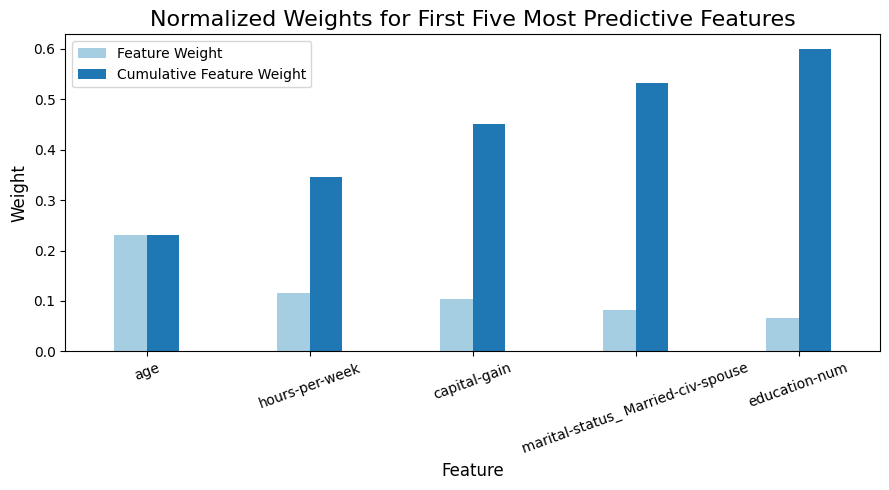

In [14]:
# TODO: Import a supervised learning model that has 'feature_importances_'
from sklearn.ensemble import RandomForestClassifier

# TODO: Train the supervised model on the training set using .fit(X_train, y_train)
model = RandomForestClassifier(random_state=42).fit(X_train, y_train)

# TODO: Extract the feature importances using .feature_importances_
importances = model.feature_importances_

# Plot
vs.feature_plot(importances, X_train, y_train)

### Question 7 - Extracting Feature Importance

Observe the visualization created above which displays the five most relevant features for predicting if an individual makes at most or above $50,000.  
* How do these five features compare to the five features you discussed in **Question 6**?
* If you were close to the same answer, how does this visualization confirm your thoughts? 
* If you were not close, why do you think these features are more relevant?

**Answer:**

The five most relevant features identified by the model are `age`, `hours-per-week`, `capital-gain`, `marital-status__Married-civ-spouse`, and `education-num`. My earlier expectations were partially correct, since I also identified `education-num`, `age`, `hours-per-week`, and `marital-status` as likely to be among the most important predictors. This confirms that demographic background, work intensity, and education level are indeed strong signals for income prediction. However, one important difference is that `capital-gain` appeared among the top features, while `occupation` did not appear in the top five as I initially expected.

This visualization confirms that some of the features I predicted were important are in fact highly influential, especially `education-num` and `age`. At the same time, it shows that `capital-gain` is more relevant than I initially assumed, likely because it provides a strong direct signal of financial status and wealth accumulation, which are closely related to higher income. The presence of `marital-status__Married-civ-spouse` also suggests that household and life-stage patterns are strongly associated with earnings. Overall, the plot helps validate the general intuition behind the earlier ranking while also revealing that the model detected some patterns, especially around capital gains, that are more informative than they may seem at first glance.

### Feature Selection
How does a model perform if we only use a subset of all the available features in the data? With less features required to train, the expectation is that training and prediction time is much lower — at the cost of performance metrics. From the visualization above, we see that the top five most important features contribute more than half of the importance of **all** features present in the data. This hints that we can attempt to *reduce the feature space* and simplify the information required for the model to learn. The code cell below will use the same optimized model you found earlier, and train it on the same training set *with only the top five important features*. 

In [15]:
# Import functionality for cloning a model
from sklearn.base import clone

# Reduce the feature space
X_train_reduced = X_train[X_train.columns.values[(np.argsort(importances)[::-1])[:5]]]
X_test_reduced = X_test[X_test.columns.values[(np.argsort(importances)[::-1])[:5]]]

# Train on the "best" model found from grid search earlier
clf = (clone(best_clf)).fit(X_train_reduced, y_train)

# Make new predictions
reduced_predictions = clf.predict(X_test_reduced)

# Report scores from the final model using both versions of data
print("Final Model trained on full data\n------")
print(
    "Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, best_predictions))
)
print(
    "F-score on testing data: {:.4f}".format(
        fbeta_score(y_test, best_predictions, beta=0.5)
    )
)
print("\nFinal Model trained on reduced data\n------")
print(
    "Accuracy on testing data: {:.4f}".format(
        accuracy_score(y_test, reduced_predictions)
    )
)
print(
    "F-score on testing data: {:.4f}".format(
        fbeta_score(y_test, reduced_predictions, beta=0.5)
    )
)

Final Model trained on full data
------
Accuracy on testing data: 0.8719
F-score on testing data: 0.7581

Final Model trained on reduced data
------
Accuracy on testing data: 0.8526
F-score on testing data: 0.7172


### Question 8 - Effects of Feature Selection

* How does the final model's F-score and accuracy score on the reduced data using only five features compare to those same scores when all features are used?
* If training time was a factor, would you consider using the reduced data as your training set?

**Answer:**
Use this in the notebook:

**Answer:**

When the final model was trained on the full dataset, it achieved an accuracy of `0.8719` and an F-score of `0.7581`. Using only the top five features, performance decreased to an accuracy of `0.8526` and an F-score of `0.7172`. This shows that reducing the feature space led to a noticeable drop in predictive quality. Although the reduced model still performs reasonably well, the full model is clearly better at identifying high-income individuals and provides a stronger balance between precision and recall.

If training time were an important constraint, I would consider using the reduced dataset because it would likely train faster and still retain much of the predictive signal in the data. However, if predictive performance is the main priority, I would prefer the full dataset. In this case, the reduction in F-score is meaningful enough that I would only choose the reduced feature set if the gain in speed or simplicity were necessary for operational reasons.

> **Note**: Once you have completed all of the code implementations and successfully answered each question above, you may finalize your work by exporting the iPython Notebook as an HTML document. You can do this by using the menu above and navigating to  
**File -> Download as -> HTML (.html)**. Include the finished document along with this notebook as your submission.